# Test Độ Nhạy của Optimizer với Reproducibility trên TPU v6e-1

**TPU Target**: Google Cloud TPU v6e-1  
**Architecture**: v6e (Edge TPU)  
**TF32 Support**: ❌ Không hỗ trợ (TF32 là tính năng NVIDIA GPU)  
**Precision**: BFloat16 (mặc định cho TPU), FP32

**Mục tiêu**: Chứng minh rằng các optimizer khác nhau (Adam, RMSProp) có độ nhạy khác nhau với các sai số nhỏ trên TPU v6e-1, dẫn đến khuếch đại sự khác biệt giữa các GPU/TPU.

**Vấn đề**: Optimizer như Adam và RMSProp sử dụng momentum và adaptive learning rate, có thể khuếch đại sai số nhỏ từ floating-point precision thành khác biệt lớn hơn.


## 1. Cài đặt torch_xla và kiểm tra TPU


In [1]:
# Cài đặt torch_xla (chạy lần đầu tiên)
# !pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools
# Import torch_xla cho TPU
try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    import torch_xla.distributed.parallel_loader as pl
    # Import runtime module cho world_size (torch_xla 2.7+)
    try:
        import torch_xla.runtime as xr
        RUNTIME_AVAILABLE = True
    except ImportError:
        RUNTIME_AVAILABLE = False
    TPU_AVAILABLE = True
    print(f"torch_xla version: {torch_xla.__version__}")
except ImportError:
    TPU_AVAILABLE = False
    RUNTIME_AVAILABLE = False
    print("⚠️  torch_xla chưa được cài đặt!")
    print("   Chạy: !pip install torch_xla[tpu] -f https://storage.googleapis.com/libtpu-releases/index.html")

# Kiểm tra TPU
print(f"\nPyTorch version: {torch.__version__}")
if TPU_AVAILABLE:
    # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
    try:
        device = torch_xla.device()
    except:
        device = xm.xla_device()  # Fallback cho phiên bản cũ
    print(f"TPU Device: {device}")

    # Lấy device hardware info
    try:
        device_hw = xm.xla_device_hw(device)
        print(f"TPU Device Type: {device_hw}")
    except:
        device_hw = "Unknown"
        print(f"TPU Device Type: {device_hw}")

    # Kiểm tra số TPU cores - sử dụng API mới
    try:
        if RUNTIME_AVAILABLE:
            num_cores = xr.world_size()
        else:
            # Fallback: thử API cũ hoặc đặt mặc định
            try:
                num_cores = xm.xrt_world_size()
            except:
                num_cores = 1  # Mặc định nếu không lấy được
        print(f"Số TPU cores: {num_cores}")
    except Exception as e:
        print(f"Không thể lấy số TPU cores: {e}")
        num_cores = 1

    # Xác nhận TPU v6e-1
    if "v6e" in device_hw.lower() or "v6" in device_hw.lower():
        print(f"\n✓ Đã xác nhận: TPU v6e")
    else:
        print(f"\n⚠️  CẢNH BÁO: TPU hiện tại ({device_hw}) có thể không phải v6e-1!")
        print("   Notebook này được thiết kế cho TPU v6e-1.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
else:
    print("❌ Không tìm thấy TPU hoặc torch_xla chưa được cài đặt!")
    print("   Vui lòng cài đặt torch_xla và đảm bảo bạn đang chạy trên TPU VM hoặc Colab với TPU.")


torch_xla version: 2.9.0

PyTorch version: 2.9.0+cpu
TPU Device: xla:0
TPU Device Type: TPU
Số TPU cores: 1

⚠️  CẢNH BÁO: TPU hiện tại (TPU) có thể không phải v6e-1!
   Notebook này được thiết kế cho TPU v6e-1.
   Vẫn tiếp tục nhưng kết quả có thể khác.


## 2. Định nghĩa các hàm helper


In [2]:
def _worker_init_fn(worker_id, seed_val=42):
    """Worker init function cho DataLoader (phai la top-level function de pickle duoc)"""
    np.random.seed(seed_val + worker_id)

def set_seed(seed=42):
    """Thiết lập seed cho tất cả các RNG để đảm bảo reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    # TPU không có cuda, nên không cần torch.cuda.manual_seed

class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    """Load CIFAR-10 (tối ưu cho Linux/Unix)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    # Set seed cho DataLoader - su dung functools.partial voi function doc lap
    # (tranh loi pickle voi nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


## 3. Hàm training với các optimizer khác nhau (cho TPU)


In [3]:
def train_with_optimizer(optimizer_name, seed=42, num_epochs=10, lr=0.001,
                         bf16_enabled=True, save_results=True):
    """Train với optimizer cụ thể trên TPU"""
    if not TPU_AVAILABLE:
        print("❌ TPU không khả dụng! Vui lòng cài đặt torch_xla và đảm bảo bạn đang chạy trên TPU.")
        return None

    set_seed(seed)

    # Sử dụng torch_xla.device() thay vì xm.xla_device() (deprecated)
    try:
        device = torch_xla.device()
    except:
        device = xm.xla_device()  # Fallback cho phiên bản cũ

    trainloader, testloader = get_cifar10_loaders(batch_size=128, num_workers=4, seed=seed)

    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()

    # Tạo optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name.lower() == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Lấy TPU name
    try:
        tpu_name = xm.xla_device_hw(device)
        device_name = f"TPU {tpu_name}"
    except:
        tpu_name = 'Unknown'
        device_name = 'TPU Unknown'

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'optimizer': optimizer_name,
        'seed': seed,
        'lr': lr,
        'bf16_enabled': bf16_enabled,
        'gpu_name': device_name,  # Tương thích với notebook phân tích
        'tpu_name': tpu_name
    }

    print(f"\n{'='*70}")
    print(f"Training với {optimizer_name.upper()} trên TPU")
    print(f"  TPU: {device_name}")
    print(f"  BFloat16: {bf16_enabled}")
    print(f"  Seed: {seed}")
    print(f"  LR: {lr}")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            # TPU sử dụng bfloat16 mặc định
            if bf16_enabled:
                # Sử dụng torch.autocast với device_type='xla' cho TPU
                with torch.autocast(device_type='xla', dtype=torch.bfloat16):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            loss.backward()

            # Sử dụng xm.optimizer_step() cho TPU thay vì optimizer.step()
            xm.optimizer_step(optimizer)

            # Đồng bộ TPU sau mỗi step
            xm.mark_step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total

        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

                # Đồng bộ TPU
                xm.mark_step()

        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f"results/optimizer_tpu_v6e1_{optimizer_name.lower()}_seed_{seed}_{timestamp}.json"
        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")

    return history


## 4. Test với các optimizer khác nhau (cùng seed, cùng TPU)


In [4]:
# Test với Adam
history_adam = train_with_optimizer('Adam', seed=42, num_epochs=10, bf16_enabled=True)


100%|██████████| 170M/170M [00:16<00:00, 10.5MB/s]



Training với ADAM trên TPU
  TPU: TPU TPU
  BFloat16: True
  Seed: 42
  LR: 0.001



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-3027096355.py:87: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-3027096355.py:115: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.4508, Train Acc: 46.49% | Test Loss: 1.1383, Test Acc: 58.69%
Epoch 2/10: Train Loss: 1.1394, Train Acc: 59.30% | Test Loss: 0.9153, Test Acc: 67.63%
Epoch 3/10: Train Loss: 1.0214, Train Acc: 63.55% | Test Loss: 0.8735, Test Acc: 69.16%
Epoch 4/10: Train Loss: 0.9399, Train Acc: 66.63% | Test Loss: 0.8367, Test Acc: 70.52%
Epoch 5/10: Train Loss: 0.8926, Train Acc: 68.41% | Test Loss: 0.7595, Test Acc: 73.30%
Epoch 6/10: Train Loss: 0.8539, Train Acc: 69.62% | Test Loss: 0.7481, Test Acc: 73.44%
Epoch 7/10: Train Loss: 0.8218, Train Acc: 70.76% | Test Loss: 0.6976, Test Acc: 75.68%
Epoch 8/10: Train Loss: 0.7926, Train Acc: 72.08% | Test Loss: 0.6724, Test Acc: 76.50%
Epoch 9/10: Train Loss: 0.7585, Train Acc: 73.27% | Test Loss: 0.6684, Test Acc: 76.89%
Epoch 10/10: Train Loss: 0.7469, Train Acc: 73.54% | Test Loss: 0.6555, Test Acc: 76.82%

✓ Kết quả đã lưu: results/optimizer_tpu_v6e1_adam_seed_42_20251226_084145.json


In [5]:
# Test với RMSProp
history_rmsprop = train_with_optimizer('RMSprop', seed=42, num_epochs=10, bf16_enabled=True)



Training với RMSPROP trên TPU
  TPU: TPU TPU
  BFloat16: True
  Seed: 42
  LR: 0.001



/tmp/ipython-input-3027096355.py:87: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-3027096355.py:115: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.6876, Train Acc: 40.99% | Test Loss: 1.3113, Test Acc: 51.27%
Epoch 2/10: Train Loss: 1.2579, Train Acc: 54.28% | Test Loss: 1.1785, Test Acc: 57.13%
Epoch 3/10: Train Loss: 1.1111, Train Acc: 60.02% | Test Loss: 1.1829, Test Acc: 57.81%
Epoch 4/10: Train Loss: 1.0265, Train Acc: 63.41% | Test Loss: 1.0611, Test Acc: 63.62%
Epoch 5/10: Train Loss: 0.9646, Train Acc: 65.60% | Test Loss: 0.8208, Test Acc: 71.03%
Epoch 6/10: Train Loss: 0.9234, Train Acc: 67.11% | Test Loss: 1.1821, Test Acc: 59.41%
Epoch 7/10: Train Loss: 0.8902, Train Acc: 68.54% | Test Loss: 0.8966, Test Acc: 68.32%
Epoch 8/10: Train Loss: 0.8587, Train Acc: 69.65% | Test Loss: 1.0091, Test Acc: 65.05%
Epoch 9/10: Train Loss: 0.8287, Train Acc: 70.52% | Test Loss: 0.7752, Test Acc: 72.20%
Epoch 10/10: Train Loss: 0.8037, Train Acc: 71.64% | Test Loss: 0.6930, Test Acc: 75.35%

✓ Kết quả đã lưu: results/optimizer_tpu_v6e1_rmsprop_seed_42_20251226_084254.json


In [6]:
# Test với SGD (để so sánh)
history_sgd = train_with_optimizer('SGD', seed=42, num_epochs=10, bf16_enabled=True)



Training với SGD trên TPU
  TPU: TPU TPU
  BFloat16: True
  Seed: 42
  LR: 0.001



/tmp/ipython-input-3027096355.py:87: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-3027096355.py:115: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.8359, Train Acc: 32.62% | Test Loss: 1.4748, Test Acc: 45.60%
Epoch 2/10: Train Loss: 1.4846, Train Acc: 45.39% | Test Loss: 1.2741, Test Acc: 53.63%
Epoch 3/10: Train Loss: 1.3483, Train Acc: 51.18% | Test Loss: 1.1773, Test Acc: 57.34%
Epoch 4/10: Train Loss: 1.2652, Train Acc: 54.34% | Test Loss: 1.0634, Test Acc: 62.72%
Epoch 5/10: Train Loss: 1.1995, Train Acc: 57.20% | Test Loss: 1.0509, Test Acc: 62.84%
Epoch 6/10: Train Loss: 1.1507, Train Acc: 58.97% | Test Loss: 0.9833, Test Acc: 65.34%
Epoch 7/10: Train Loss: 1.1148, Train Acc: 60.09% | Test Loss: 0.9478, Test Acc: 66.69%
Epoch 8/10: Train Loss: 1.0838, Train Acc: 61.51% | Test Loss: 0.9368, Test Acc: 66.62%
Epoch 9/10: Train Loss: 1.0491, Train Acc: 62.91% | Test Loss: 0.9019, Test Acc: 68.35%
Epoch 10/10: Train Loss: 1.0321, Train Acc: 63.35% | Test Loss: 0.8855, Test Acc: 69.05%

✓ Kết quả đã lưu: results/optimizer_tpu_v6e1_sgd_seed_42_20251226_084354.json


## 5. So sánh kết quả giữa các optimizer


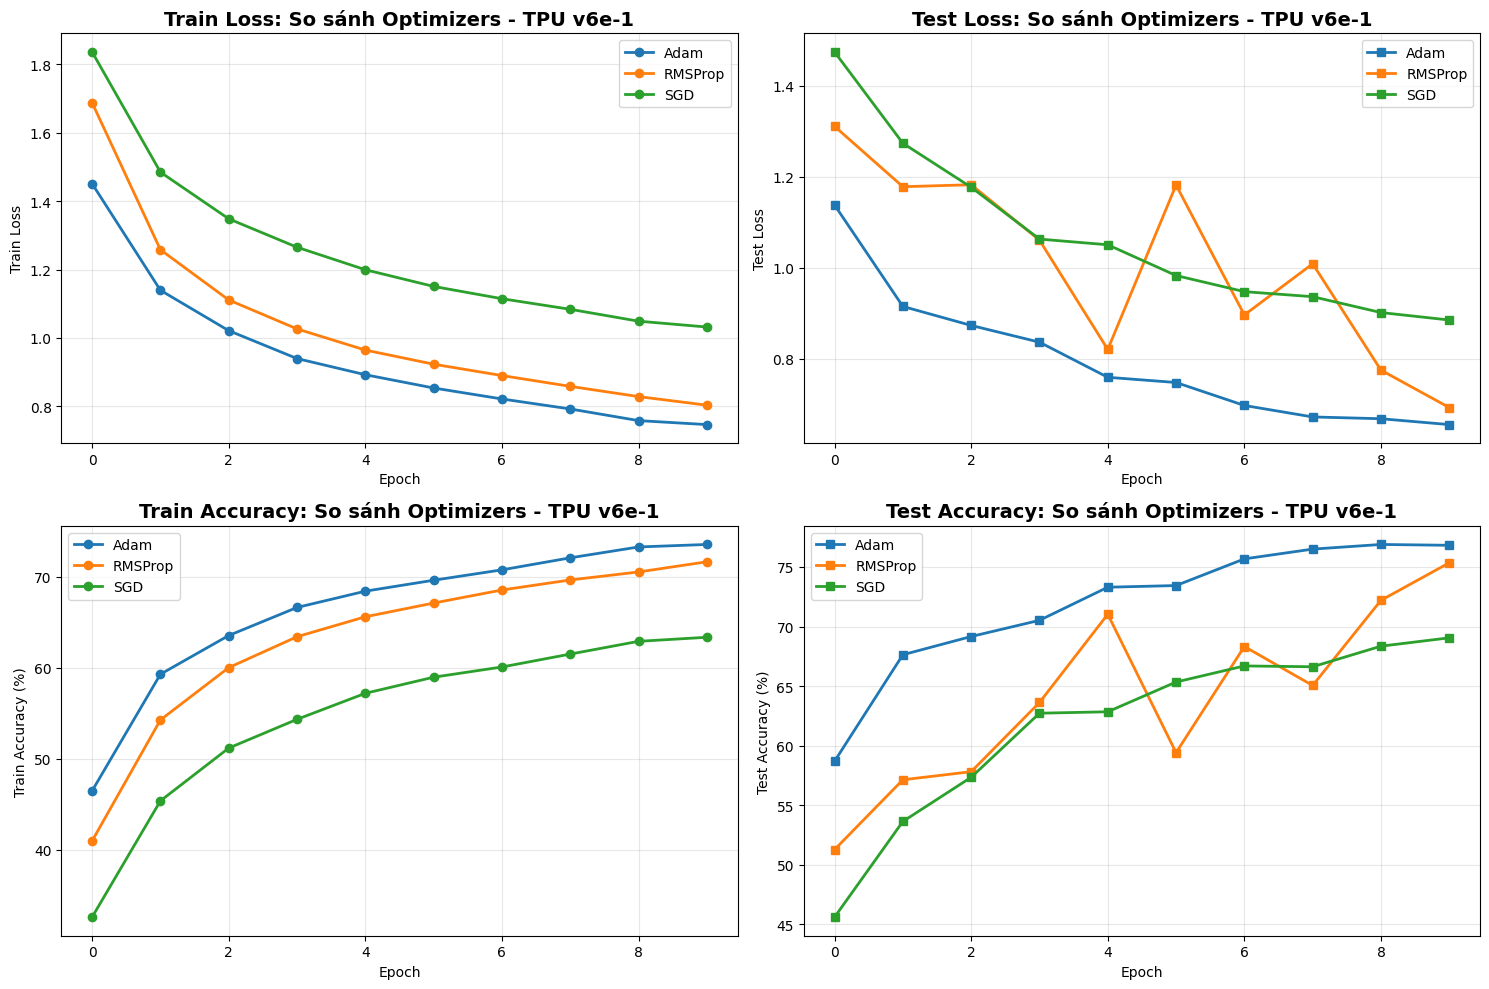


SO SÁNH CÁC OPTIMIZER - TPU v6e-1
Optimizer       Final Train Loss   Final Test Loss    Final Test Acc    
--------------------------------------------------------------------------------
Adam            0.7469             0.6555             76.82             %
RMSProp         0.8037             0.6930             75.35             %
SGD             1.0321             0.8855             69.05             %


In [7]:
def compare_optimizers(histories, labels):
    """So sánh kết quả giữa các optimizer"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss: So sánh Optimizers - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss: So sánh Optimizers - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Accuracy (%)')
    ax.set_title('Train Accuracy: So sánh Optimizers - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy: So sánh Optimizers - TPU v6e-1', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/optimizers_comparison_TPU_v6e1.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bảng so sánh
    print("\n" + "="*80)
    print("SO SÁNH CÁC OPTIMIZER - TPU v6e-1")
    print("="*80)
    print(f"{'Optimizer':<15} {'Final Train Loss':<18} {'Final Test Loss':<18} {'Final Test Acc':<18}")
    print("-"*80)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<15} {final_train_loss:<18.4f} {final_test_loss:<18.4f} {final_test_acc:<18.2f}%")
    print("="*80)

if 'history_adam' in globals() and 'history_rmsprop' in globals() and 'history_sgd' in globals():
    if history_adam is not None and history_rmsprop is not None and history_sgd is not None:
        compare_optimizers([history_adam, history_rmsprop, history_sgd],
                           ['Adam', 'RMSProp', 'SGD'])


## 6. Test độ nhạy: Chạy nhiều lần với cùng optimizer và seed

Để thấy rõ độ nhạy của optimizer với sai số nhỏ, ta sẽ chạy nhiều lần với cùng cấu hình.


TEST ĐỘ NHẠY: Chạy Adam 3 lần với cùng seed trên TPU v6e-1

--- Run 1/3 ---

Training với ADAM trên TPU
  TPU: TPU TPU
  BFloat16: True
  Seed: 42
  LR: 0.001



/tmp/ipython-input-3027096355.py:87: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()
/tmp/ipython-input-3027096355.py:115: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()


Epoch 1/10: Train Loss: 1.4563, Train Acc: 46.50% | Test Loss: 1.0882, Test Acc: 60.52%
Epoch 2/10: Train Loss: 1.1390, Train Acc: 58.93% | Test Loss: 0.9676, Test Acc: 65.43%
Epoch 3/10: Train Loss: 1.0147, Train Acc: 64.05% | Test Loss: 0.8599, Test Acc: 69.82%
Epoch 4/10: Train Loss: 0.9531, Train Acc: 66.04% | Test Loss: 0.8472, Test Acc: 70.53%
Epoch 5/10: Train Loss: 0.8969, Train Acc: 68.20% | Test Loss: 0.7973, Test Acc: 71.96%
Epoch 6/10: Train Loss: 0.8555, Train Acc: 69.63% | Test Loss: 0.7362, Test Acc: 73.73%
Epoch 7/10: Train Loss: 0.8277, Train Acc: 70.56% | Test Loss: 0.6979, Test Acc: 75.78%
Epoch 8/10: Train Loss: 0.7994, Train Acc: 71.54% | Test Loss: 0.6685, Test Acc: 76.49%
Epoch 9/10: Train Loss: 0.7698, Train Acc: 72.91% | Test Loss: 0.6653, Test Acc: 76.60%
Epoch 10/10: Train Loss: 0.7530, Train Acc: 73.51% | Test Loss: 0.6672, Test Acc: 76.24%

--- Run 2/3 ---

Training với ADAM trên TPU
  TPU: TPU TPU
  BFloat16: True
  Seed: 42
  LR: 0.001

Epoch 1/10: Train 

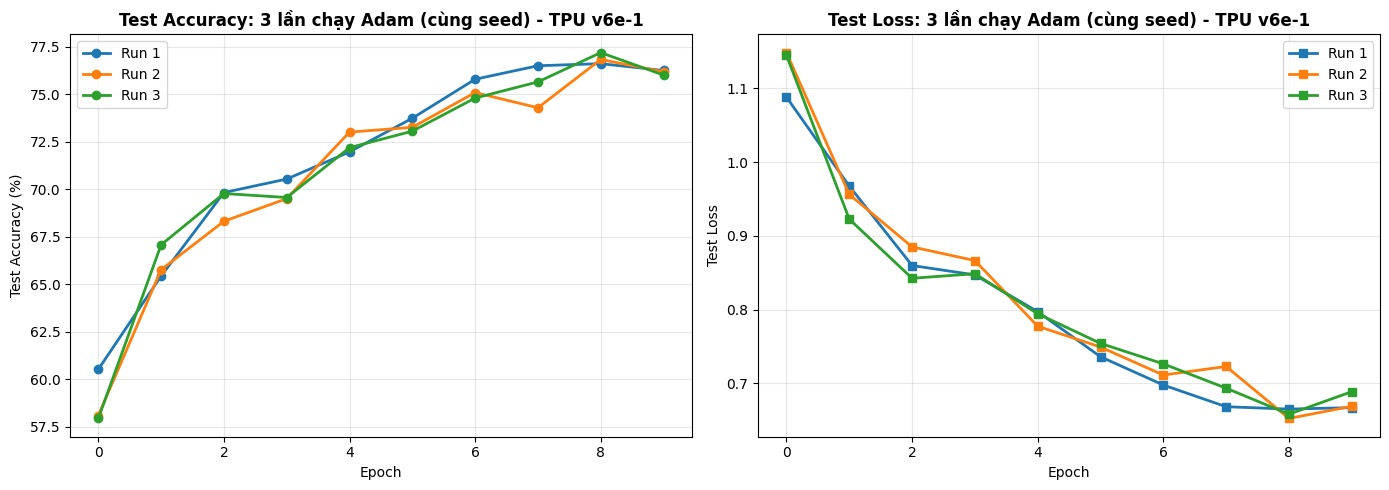

In [8]:
# Chạy Adam 3 lần với cùng seed (nhưng mỗi lần khởi tạo model lại)
print("="*80)
print("TEST ĐỘ NHẠY: Chạy Adam 3 lần với cùng seed trên TPU v6e-1")
print("="*80)

adam_runs = []
for run in range(3):
    print(f"\n--- Run {run+1}/3 ---")
    history = train_with_optimizer('Adam', seed=42, num_epochs=10, bf16_enabled=True, save_results=False)
    if history is not None:
        adam_runs.append(history)

# So sánh các lần chạy
if len(adam_runs) > 0:
    print("\n" + "="*80)
    print("SO SÁNH CÁC LẦN CHẠY ADAM (cùng seed) - TPU v6e-1")
    print("="*80)
    print(f"{'Run':<10} {'Final Test Acc':<18} {'Độ lệch so với Run 1':<20}")
    print("-"*80)
    baseline_acc = adam_runs[0]['test_acc'][-1]
    for i, hist in enumerate(adam_runs):
        acc = hist['test_acc'][-1]
        diff = acc - baseline_acc
        print(f"Run {i+1:<9} {acc:<18.2f}% {diff:+.2f}%")

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for i, hist in enumerate(adam_runs):
        ax.plot(hist['test_acc'], label=f'Run {i+1}', marker='o', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy: 3 lần chạy Adam (cùng seed) - TPU v6e-1', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for i, hist in enumerate(adam_runs):
        ax.plot(hist['test_loss'], label=f'Run {i+1}', marker='s', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss: 3 lần chạy Adam (cùng seed) - TPU v6e-1', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/adam_sensitivity_test_TPU_v6e1.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7. Kết luận cho TPU v6e-1

**Đặc điểm TPU v6e-1**:
- Architecture: v6e (Edge TPU)
- ❌ Không hỗ trợ TF32 (đây là tính năng NVIDIA GPU)
- ✅ Hỗ trợ BFloat16 (mặc định cho hiệu suất tốt hơn)
- ✅ Hỗ trợ FP32

**Quan sát từ các test trên TPU v6e-1**:

1. **Adam và RMSProp** là các adaptive optimizer, sử dụng momentum và learning rate adaptation
2. Các optimizer này **khuếch đại sai số nhỏ** từ floating-point precision
3. Ngay cả với cùng seed, mỗi lần khởi tạo model lại có thể cho kết quả hơi khác nhau
4. Sự khác biệt tích lũy qua các epoch do:
   - Adaptive learning rate thay đổi dựa trên gradient history
   - Momentum tích lũy sai số nhỏ
   - BatchNorm và Dropout cũng góp phần vào non-determinism
   - **XLA Compilation**: TPU sử dụng XLA compiler, có thể tạo ra các kernel khác nhau giữa các lần chạy

**Tác động lên Cross-GPU/TPU Reproducibility**:

- Trên GPU/TPU khác nhau, sai số floating-point khác nhau
- Optimizer khuếch đại sự khác biệt này
- Dẫn đến kết quả cuối cùng có thể khác nhau đáng kể
- TPU sử dụng bfloat16 mặc định, có thể có khác biệt so với FP32 trên GPU

**Khuyến nghị cho TPU v6e-1**:

- Hiểu rằng adaptive optimizers (Adam, RMSProp) nhạy cảm hơn với sai số
- Khi so sánh kết quả, tập trung vào **xu hướng** chứ không phải giá trị tuyệt đối
- Nếu cần reproducibility cao, cân nhắc dùng SGD với momentum cố định
- Lưu ý rằng XLA compilation có thể tạo ra các kernel khác nhau giữa các lần chạy

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/` với tên TPU v6e-1
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (T4, L4, A100, RTX 3060, H100)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh giữa TPU và GPU
